# BIU Portfolio Risk Analysis

A SQL-driven look at the loan portfolio underlying CrediSure's risk models -- the kind of ad-hoc business question a Business Intelligence Unit gets asked directly ("which segments carry more default risk?", "where is exposure concentrated?"), answered with SQL against a relational store rather than the app's operational MongoDB.

**Data**: `Loan_default.csv` (255,347 records), the same dataset used to train the credit-risk models elsewhere in this repo, loaded here as a stand-in historical portfolio -- self-contained on purpose, no live database dependency, so this runs anywhere.

**Approach**: load into a local SQLite database, then answer each question with a real SQL query (not a pandas method chain) against it.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Loan_default.csv')

conn = sqlite3.connect(':memory:')
df.to_sql('loans', conn, index=False, if_exists='replace')

pd.read_sql_query('SELECT COUNT(*) AS total_loans FROM loans', conn)


,total_loans
0,255347


## 1. Portfolio composition
What does the book actually look like, before asking anything about risk?

In [2]:
composition = pd.read_sql_query('''
    SELECT
        LoanPurpose,
        COUNT(*) AS num_loans,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM loans), 1) AS pct_of_portfolio,
        ROUND(AVG(LoanAmount), 0) AS avg_loan_amount,
        ROUND(SUM(LoanAmount), 0) AS total_exposure
    FROM loans
    GROUP BY LoanPurpose
    ORDER BY total_exposure DESC
''', conn)
composition


,LoanPurpose,num_loans,pct_of_portfolio,avg_loan_amount,total_exposure
0,Home,51286,20.1,127622.0,6.545242e+09
1,Business,51298,20.1,127142.0,6.522120e+09
2,Education,51005,20.0,127646.0,6.510575e+09
3,Auto,50844,19.9,127858.0,6.500808e+09
4,Other,50914,19.9,127630.0,6.498136e+09


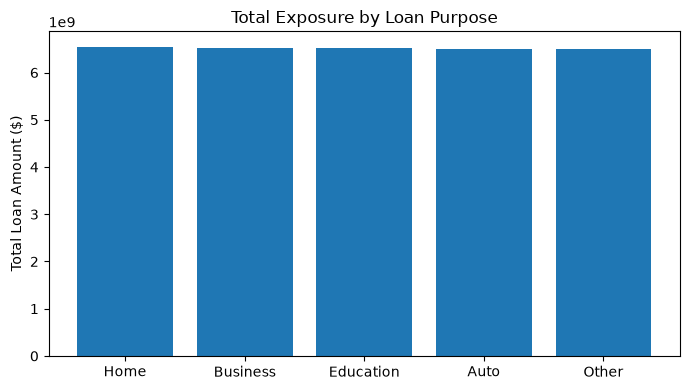

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(composition['LoanPurpose'], composition['total_exposure'])
ax.set_title('Total Exposure by Loan Purpose')
ax.set_ylabel('Total Loan Amount ($)')
plt.tight_layout()
plt.show()


## 2. Default rate by age band
A quick correlation check (done separately, not shown here) found `Age` is the single strongest predictor of `Default` in this dataset (r = -0.17) -- notably stronger than `CreditScore` (r = -0.03, close to noise). Binning age with `CASE WHEN` and grouping makes that concrete as a business-readable table.

In [4]:
age_risk = pd.read_sql_query('''
    SELECT
        CASE
            WHEN Age < 25 THEN '18-24'
            WHEN Age < 35 THEN '25-34'
            WHEN Age < 45 THEN '35-44'
            WHEN Age < 55 THEN '45-54'
            ELSE '55+'
        END AS age_band,
        COUNT(*) AS num_loans,
        ROUND(100.0 * AVG("Default"), 1) AS default_rate_pct
    FROM loans
    GROUP BY age_band
    ORDER BY age_band
''', conn)
age_risk


,age_band,num_loans,default_rate_pct
0,18-24,34176,21.0
1,25-34,49287,16.6
2,35-44,49196,12.0
3,45-54,49069,8.8
4,55+,73619,5.6


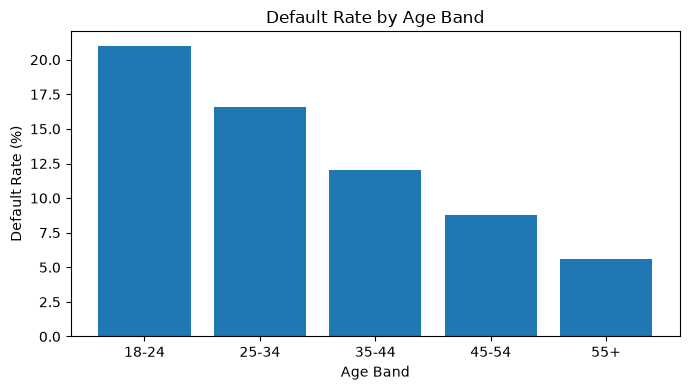

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(age_risk['age_band'], age_risk['default_rate_pct'])
ax.set_title('Default Rate by Age Band')
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Age Band')
plt.tight_layout()
plt.show()


**Finding**: default rate falls fairly steadily from the youngest to the oldest age band -- consistent with the correlation above, and a much cleaner signal than credit score gives in this dataset.

## 3. Default rate by interest rate band
`InterestRate` correlates positively with `Default` (r = 0.13) -- worth checking whether pricing already reflects some of the risk the portfolio is carrying.

In [6]:
rate_risk = pd.read_sql_query('''
    SELECT
        CASE
            WHEN InterestRate < 8 THEN 'Under 8%'
            WHEN InterestRate < 12 THEN '8-12%'
            WHEN InterestRate < 18 THEN '12-18%'
            ELSE '18%+'
        END AS rate_band,
        COUNT(*) AS num_loans,
        ROUND(100.0 * AVG("Default"), 1) AS default_rate_pct
    FROM loans
    GROUP BY rate_band
    ORDER BY MIN(InterestRate)
''', conn)
rate_risk


,rate_band,num_loans,default_rate_pct
0,Under 8%,66386,6.6
1,8-12%,44874,9.0
2,12-18%,66531,12.1
3,18%+,77556,17.0


## 4. Default rate by loan purpose
Weaker signal than age or interest rate (all purposes cluster 10-12%), but Business loans run measurably hotter than Home loans -- worth flagging even though it's not the headline finding.

In [7]:
purpose_risk = pd.read_sql_query('''
    SELECT
        LoanPurpose,
        COUNT(*) AS num_loans,
        ROUND(100.0 * AVG("Default"), 1) AS default_rate_pct
    FROM loans
    GROUP BY LoanPurpose
    ORDER BY default_rate_pct DESC
''', conn)
purpose_risk


,LoanPurpose,num_loans,default_rate_pct
0,Business,51298,12.3
1,Auto,50844,11.9
2,Other,50914,11.8
3,Education,51005,11.8
4,Home,51286,10.2


## 5. A combined high-risk segment
Putting the two real signals together (younger borrowers, higher interest rate) into one segment definition -- the kind of query a BIU would actually be asked to turn into a monitoring rule.

In [8]:
segment = pd.read_sql_query('''
    SELECT
        CASE
            WHEN Age < 35 AND InterestRate >= 12 THEN 'Young + High Rate'
            ELSE 'Rest of Portfolio'
        END AS segment,
        COUNT(*) AS num_loans,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM loans), 1) AS pct_of_portfolio,
        ROUND(100.0 * AVG("Default"), 1) AS default_rate_pct
    FROM loans
    GROUP BY segment
''', conn)
segment


,segment,num_loans,pct_of_portfolio,default_rate_pct
0,Rest of Portfolio,208269,81.6,9.0
1,Young + High Rate,47078,18.4,23.2


## Note on CreditScore and DTIRatio
Both were checked as candidate segmentation fields and dropped from the analysis above: `CreditScore` shows essentially no correlation with `Default` in this dataset (r = -0.03, confirmed separately by reading the source data directly -- it's independent of every other field, including the target), and `DTIRatio` is similarly weak here (r = 0.02). That's a genuine property of this particular dataset, not a query bug -- it's the same finding that ruled out training a usable credit-score regression model elsewhere in this project. Reporting a segmentation by a field with no real signal would be actively misleading, so `Age` and `InterestRate` -- which do carry real signal -- anchor the analysis instead.

In [9]:
conn.close()
